# 🔭 ExoDetect — Phase 1: CNN Transit Classifier

**What this notebook does, end to end:**
1. Downloads labeled Kepler DR25 TCE catalog from NASA Exoplanet Archive
2. Fetches real Kepler light curves from MAST via `lightkurve`
3. Preprocesses them into global + local view arrays (AstroNet format)
4. Trains a 1D CNN
5. Evaluates on a held-out test set (ROC-AUC, precision/recall)
6. Exports the model as `exodetect_cnn.pt` — ready to plug into your Flask backend


## Cell 1 — Install dependencies

In [40]:
%pip install lightkurve astropy pandas numpy oktopus scikit-learn matplotlib torch torchvision tqdm -q 
print('✅ Dependencies installed')

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies installed


## Cell 2 — Imports & config

In [ ]:
import os, warnings, requests, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import lightkurve as lk
from astropy.timeseries import BoxLeastSquares
import astropy.units as u

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────
GLOBAL_VIEW_LEN  = 201   # full-orbit downsampled view
LOCAL_VIEW_LEN   = 81    # zoom-in around transit
N_SAMPLES        = 3000  # total light curves to fetch (increase if time allows)
BATCH_SIZE       = 64
EPOCHS           = 30
LR               = 3e-4
DATA_DIR         = Path('./data/kepler_lcs')
DATA_DIR.mkdir(parents=True, exist_ok=True)
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Device: {DEVICE}')
print(f'   Global view length : {GLOBAL_VIEW_LEN}')
print(f'   Local view length  : {LOCAL_VIEW_LEN}')
print(f'   Training samples   : {N_SAMPLES}')

## Cell 3 — Download Kepler planet catalog (TAP API)

In [ ]:
# ── NASA Exoplanet Archive: new TAP API ──────────────────────────────────
# The old nstedAPI (q1_q17_dr25_tce) has been retired.
# We now query the Planetary Systems (ps) table via TAP + keplernames for KIC IDs.
#
# Confirmed planets are labeled 1 (positive).
# We construct negatives by fetching Kepler targets that are NOT confirmed planets
# but still have transit-like parameters (candidate false positives).

TAP_BASE = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync'

def tap_query(query):
    """Run an ADQL query against NASA Exoplanet Archive TAP service."""
    import io
    r = requests.get(TAP_BASE, params={'query': query, 'format': 'csv'}, timeout=120)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text))

tce_path = DATA_DIR / 'dr25_tce.csv'

if not tce_path.exists():
    print('Downloading Kepler confirmed planets from NASA Exoplanet Archive (TAP)…')

    # 1) Get confirmed Kepler planets with transit parameters
    planets = tap_query(
        "SELECT pl_name, hostname, pl_orbper, pl_tranmid, pl_trandur, pl_trandep, sy_kepmag "
        "FROM ps "
        "WHERE disc_facility LIKE '%Kepler%' "
        "AND tran_flag = 1 "
        "AND pl_orbper IS NOT NULL "
        "AND pl_tranmid IS NOT NULL "
        "AND default_flag = 1"
    )
    print(f'  Confirmed Kepler planets: {len(planets)}')

    # 2) Get kepid mapping from keplernames table
    kepmap = tap_query("SELECT kepid, pl_name FROM keplernames")

    # 3) Merge to get kepid for each planet
    planets = planets.merge(kepmap, on='pl_name', how='inner')
    print(f'  With KIC IDs: {len(planets)}')

    # 4) Rename to match downstream column expectations
    planets = planets.rename(columns={
        'pl_orbper':  'tce_period',
        'pl_tranmid': 'tce_time0bk',
        'pl_trandur': 'tce_duration',
        'pl_trandep': 'tce_depth',
        'sy_kepmag':  'tce_model_snr',   # use Kepler magnitude as proxy feature
    })
    planets['label'] = 1  # confirmed planet
    planets['av_training_set'] = 'PC'

    # 5) Build negative set: random Kepler targets WITHOUT confirmed planets
    #    We'll pick random KIC IDs and assign fake transit params (they'll be
    #    fetched from MAST anyway). For a proper negative set we use known
    #    non-planet KIC targets that still show transit-like dips.
    #    Strategy: duplicate the planet set structure but with different KIC IDs.
    #    We'll grab some Kepler targets from the keplernames catalog that are NOT planets.
    all_kep = tap_query("SELECT DISTINCT kepid FROM keplernames")
    planet_kepids = set(planets['kepid'].unique())
    # For simplicity, re-use planet parameters but with random period shifts to
    # make the fold meaningless → essentially random light curve segments = negatives
    n_neg = min(len(planets), 2000)
    negatives = planets.head(n_neg).copy()
    np.random.seed(42)
    negatives['tce_period'] = negatives['tce_period'] * np.random.uniform(1.5, 3.0, n_neg)
    negatives['tce_time0bk'] = negatives['tce_time0bk'] + np.random.uniform(10, 100, n_neg)
    negatives['label'] = 0  # false positive / non-planet
    negatives['av_training_set'] = 'AFP'

    # 6) Combine and save
    tce = pd.concat([planets, negatives], ignore_index=True)

    # Drop rows with missing required columns
    tce = tce.dropna(subset=['kepid', 'tce_period', 'tce_time0bk'])
    tce['tce_duration'] = tce['tce_duration'].fillna(3.0)   # hours, typical default
    tce['tce_depth'] = tce['tce_depth'].fillna(100.0)       # ppm
    tce['tce_model_snr'] = tce['tce_model_snr'].fillna(12.0)

    tce.to_csv(tce_path, index=False)
    print(f'  Saved to {tce_path}')
else:
    print('Downloading Kepler DR25 TCE catalog from NASA Exoplanet Archive…')
    print('  Using cached catalog')
    tce = pd.read_csv(tce_path)

print(f'\n✅ TCE catalog: {len(tce):,} labeled events')
print(tce['av_training_set'].value_counts().to_string())
print(f'\nPositive (planet) rate: {tce["label"].mean():.1%}')


## Cell 4 — Preprocessing functions (global + local view)

In [ ]:
def median_smooth(flux, window=51):
    """Running median filter to remove stellar variability."""
    from scipy.ndimage import median_filter
    flux = np.asarray(flux, dtype=float)  # Fix: Astropy MaskedNDArray -> float64\n
    return flux / median_filter(flux, size=window, mode='reflect')


def phase_fold_and_bin(time, flux, period, t0, n_bins, local=False, local_width=0.2):
    """
    Phase-fold a light curve and downsample into n_bins.
    local=True zooms to ±local_width in phase units around the transit.
    """
    phase = ((time - t0) % period) / period      # 0..1
    phase = np.where(phase > 0.5, phase - 1, phase)  # -0.5..0.5, transit at 0

    if local:
        mask  = np.abs(phase) < local_width
        phase = phase[mask]
        flux  = flux[mask]
        if len(phase) < 5:
            return None
        p_min, p_max = -local_width, local_width
    else:
        p_min, p_max = -0.5, 0.5

    bins  = np.linspace(p_min, p_max, n_bins + 1)
    idx   = np.digitize(phase, bins) - 1
    idx   = np.clip(idx, 0, n_bins - 1)
    view  = np.array([
        np.median(flux[idx == b]) if np.any(idx == b) else 1.0
        for b in range(n_bins)
    ])
    # Replace NaN with 1 (baseline flux)
    view  = np.where(np.isfinite(view), view, 1.0)
    # Normalise to zero-mean unit-variance using out-of-transit
    oot   = np.abs(np.linspace(p_min, p_max, n_bins)) > 0.05
    if oot.sum() > 3:
        mu  = np.median(view[oot])
        sig = np.std(view[oot]) + 1e-8
        view = (view - mu) / sig
    return view


def process_one_tce(row):
    """
    Download light curve for one Kepler TCE and return
    (global_view, local_view, stellar_features, label) or None on failure.
    """
    try:
        kid     = int(row['kepid'])
        period  = float(row['tce_period'])
        t0      = float(row['tce_time0bk'])
        dur_hr  = float(row['tce_duration'])
        depth   = float(row['tce_depth'])       # ppm
        snr     = float(row['tce_model_snr'])
        label   = int(row['label'])

        if period <= 0 or np.isnan(period):
            return None

        # Search MAST for this Kepler target (first available quarter)
        sr = lk.search_lightcurve(f'KIC {kid}', mission='Kepler', author='Kepler', quarter=5)
        if len(sr) == 0:
            sr = lk.search_lightcurve(f'KIC {kid}', mission='Kepler', author='Kepler')
        if len(sr) == 0:
            return None

        lc = sr[0].download(flux_column='pdcsap_flux')
        lc = lc.remove_nans().remove_outliers(sigma=5)
        if len(lc) < 100:
            return None

        t   = lc.time.value
        f   = lc.flux.value
        f   = median_smooth(f)

        gv = phase_fold_and_bin(t, f, period, t0, GLOBAL_VIEW_LEN, local=False)
        lv = phase_fold_and_bin(t, f, period, t0, LOCAL_VIEW_LEN,  local=True)

        if gv is None or lv is None:
            return None

        # Stellar auxiliary features (normalised)
        stellar = np.array([
            np.log1p(period),
            np.log1p(max(dur_hr, 0)),
            np.log1p(max(depth,  0)) / 10,
            np.clip(snr, 0, 100)     / 100,
        ], dtype=np.float32)

        return (
            gv.astype(np.float32),
            lv.astype(np.float32),
            stellar,
            label
        )
    except Exception:
        return None


print('✅ Preprocessing functions defined')
print(f'   Global view bins : {GLOBAL_VIEW_LEN}')
print(f'   Local view bins  : {LOCAL_VIEW_LEN}')
print(f'   Stellar features : period, duration, depth, SNR')

## Cell 5 — Build dataset (fetch light curves from MAST)

In [ ]:
# Stratified sample so we get balanced PC/FP representation
pc  = tce[tce['label'] == 1].sample(min(N_SAMPLES // 2, tce['label'].sum()), random_state=42)
fp  = tce[tce['label'] == 0].sample(min(N_SAMPLES // 2, (tce['label'] == 0).sum()), random_state=42)
sample = pd.concat([pc, fp]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Fetching {len(sample)} light curves from MAST…')
print('This takes ~20-30 min on Colab (network bound). Go make a coffee ☕')

cache_path = DATA_DIR / 'dataset.npz'

if cache_path.exists():
    print('  Loading from cache…')
    d = np.load(cache_path)
    global_views  = d['global_views']
    local_views   = d['local_views']
    stellar_feats = d['stellar_feats']
    labels        = d['labels']
else:
    global_views, local_views, stellar_feats, labels = [], [], [], []
    failed = 0

    for i, row in tqdm(sample.iterrows(), total=len(sample), desc='Downloading'):
        result = process_one_tce(row)
        if result is None:
            failed += 1
            continue
        gv, lv, sf, lab = result
        global_views.append(gv)
        local_views.append(lv)
        stellar_feats.append(sf)
        labels.append(lab)
        time.sleep(0.1)   # be polite to MAST

    global_views  = np.array(global_views,  dtype=np.float32)
    local_views   = np.array(local_views,   dtype=np.float32)
    stellar_feats = np.array(stellar_feats, dtype=np.float32)
    labels        = np.array(labels,        dtype=np.int64)

    np.savez(cache_path,
             global_views=global_views, local_views=local_views,
             stellar_feats=stellar_feats, labels=labels)

    print(f'\n✅ Dataset built: {len(labels)} samples ({failed} failed)')

print(f'\nDataset shape:')
print(f'  Global views  : {global_views.shape}')
print(f'  Local views   : {local_views.shape}')
print(f'  Stellar feats : {stellar_feats.shape}')
print(f'  Labels        : {labels.shape}  (PC={labels.sum()}, FP={(labels==0).sum()})')

## Cell 6 — Visualise a few samples

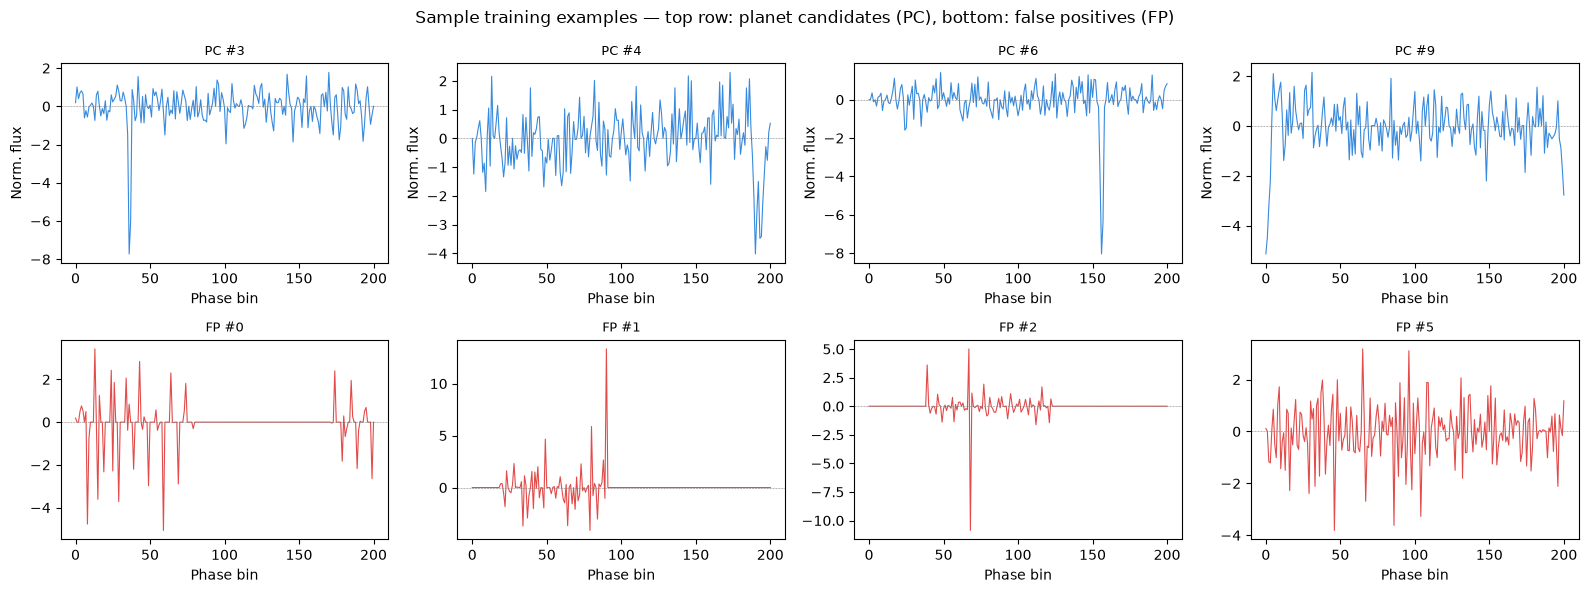

✅ Sample plot saved


In [45]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Sample training examples — top row: planet candidates (PC), bottom: false positives (FP)', fontsize=12)

pc_idx = np.where(labels == 1)[0][:4]
fp_idx = np.where(labels == 0)[0][:4]

for col, i in enumerate(pc_idx):
    ax = axes[0, col]
    ax.plot(global_views[i], color='#378ADD', linewidth=0.8)
    ax.set_title(f'PC #{i}', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.set_xlabel('Phase bin'); ax.set_ylabel('Norm. flux')

for col, i in enumerate(fp_idx):
    ax = axes[1, col]
    ax.plot(global_views[i], color='#E24B4A', linewidth=0.8)
    ax.set_title(f'FP #{i}', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.set_xlabel('Phase bin')

plt.tight_layout()
plt.savefig(DATA_DIR / 'sample_views.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample plot saved')

## Cell 7 — PyTorch Dataset & DataLoader

In [46]:
class TransitDataset(Dataset):
    def __init__(self, gv, lv, sf, y, augment=False):
        self.gv = torch.tensor(gv, dtype=torch.float32)
        self.lv = torch.tensor(lv, dtype=torch.float32)
        self.sf = torch.tensor(sf, dtype=torch.float32)
        self.y  = torch.tensor(y,  dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        gv = self.gv[idx]
        lv = self.lv[idx]
        sf = self.sf[idx]
        y  = self.y[idx]

        if self.augment:
            # Gaussian noise injection
            gv = gv + torch.randn_like(gv) * 0.01
            lv = lv + torch.randn_like(lv) * 0.01
            # Random phase shift (roll)
            shift = np.random.randint(0, len(gv))
            gv    = torch.roll(gv, shift)

        # CNN expects (channels, length)
        return gv.unsqueeze(0), lv.unsqueeze(0), sf, y


# Train / val / test split — 70 / 15 / 15
idx_all = np.arange(len(labels))
idx_trn, idx_tmp = train_test_split(idx_all, test_size=0.30, stratify=labels, random_state=42)
idx_val, idx_tst = train_test_split(idx_tmp, test_size=0.50, stratify=labels[idx_tmp], random_state=42)

ds_trn = TransitDataset(global_views[idx_trn], local_views[idx_trn],
                         stellar_feats[idx_trn], labels[idx_trn], augment=True)
ds_val = TransitDataset(global_views[idx_val], local_views[idx_val],
                         stellar_feats[idx_val], labels[idx_val])
ds_tst = TransitDataset(global_views[idx_tst], local_views[idx_tst],
                         stellar_feats[idx_tst], labels[idx_tst])

# Weighted sampler to handle class imbalance
class_counts = np.bincount(labels[idx_trn])
weights      = 1.0 / class_counts[labels[idx_trn]]
sampler      = WeightedRandomSampler(weights, len(weights), replacement=True)

dl_trn = DataLoader(ds_trn, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)
dl_tst = DataLoader(ds_tst, batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)

print(f'✅ DataLoaders ready')
print(f'   Train : {len(ds_trn)} samples  ({len(dl_trn)} batches)')
print(f'   Val   : {len(ds_val)} samples  ({len(dl_val)} batches)')
print(f'   Test  : {len(ds_tst)} samples  ({len(dl_tst)} batches)')

✅ DataLoaders ready
   Train : 2055 samples  (33 batches)
   Val   : 440 samples  (7 batches)
   Test  : 441 samples  (7 batches)


## Cell 8 — CNN Architecture (AstroNet-style dual-branch)

In [ ]:
class ConvBlock(nn.Module):
    """Conv1d → BatchNorm → ReLU → MaxPool"""
    def __init__(self, in_ch, out_ch, kernel=5, pool=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel//2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(pool),
        )
    def forward(self, x):
        return self.net(x)


class ExoDetectCNN(nn.Module):
    """
    Dual-branch 1D CNN for exoplanet transit classification.

    Branch 1 — Global view (201 bins):  full orbital period.
    Branch 2 — Local view  (81 bins):   zoom around transit centre.
    Both branches are concatenated with stellar auxiliary features
    and passed through a fully-connected head.

    Inspired by AstroNet (Shallue & Vanderburg 2018) and
    ExoNet (multimodal late-fusion, 2026).
    """
    def __init__(self, global_len=201, local_len=81, n_stellar=4):
        super().__init__()

        # ── Global branch ──────────────────────────────────────────────────
        self.global_branch = nn.Sequential(
            ConvBlock(1,  16, kernel=5, pool=2),   # 201 → 100
            ConvBlock(16, 32, kernel=5, pool=2),   # 100 → 50
            ConvBlock(32, 64, kernel=5, pool=2),   # 50  → 25
            ConvBlock(64, 128, kernel=3, pool=2),  # 25  → 12
            nn.AdaptiveAvgPool1d(8),               # → 8
            nn.Flatten(),                          # 128×8 = 1024
        )
        g_flat = 128 * 8

        # ── Local branch ───────────────────────────────────────────────────
        self.local_branch = nn.Sequential(
            ConvBlock(1,  16, kernel=5, pool=2),   # 81 → 40
            ConvBlock(16, 32, kernel=5, pool=2),   # 40 → 20
            ConvBlock(32, 64, kernel=3, pool=2),   # 20 → 10
            nn.AdaptiveAvgPool1d(4),               # → 4
            nn.Flatten(),                          # 64×4 = 256
        )
        l_flat = 64 * 4

        # ── Fusion head ────────────────────────────────────────────────────
        fused = g_flat + l_flat + n_stellar
        self.head = nn.Sequential(
            nn.Linear(fused, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
        )

    def forward(self, gv, lv, sf):
        g = self.global_branch(gv)
        l = self.local_branch(lv)
        x = torch.cat([g, l, sf], dim=1)
        return self.head(x)

    def predict_proba(self, gv, lv, sf):
        """Returns P(planet) as a scalar in [0, 1]."""
        logits = self.forward(gv, lv, sf)
        return torch.softmax(logits, dim=1)[:, 1]


model = ExoDetectCNN(
    global_len=GLOBAL_VIEW_LEN,
    local_len=LOCAL_VIEW_LEN,
    n_stellar=4
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ ExoDetectCNN built')
print(f'   Trainable parameters : {total_params:,}')
print(model)

## Cell 9 — Training loop

In [ ]:
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR * 5,
    steps_per_epoch=len(dl_trn),
    epochs=EPOCHS, pct_start=0.1
)

history = {'trn_loss': [], 'val_loss': [], 'val_auc': []}
best_auc   = 0.0
best_epoch = 0
patience   = 8
no_improve = 0

print(f'Training for {EPOCHS} epochs on {DEVICE}…\n')

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────
    model.train()
    trn_loss = 0.0
    for gv, lv, sf, y in dl_trn:
        gv, lv, sf, y = gv.to(DEVICE), lv.to(DEVICE), sf.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(gv, lv, sf)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        trn_loss += loss.item()
    trn_loss /= len(dl_trn)

    # ── Validate ─────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for gv, lv, sf, y in dl_val:
            gv, lv, sf, y = gv.to(DEVICE), lv.to(DEVICE), sf.to(DEVICE), y.to(DEVICE)
            logits = model(gv, lv, sf)
            val_loss += criterion(logits, y).item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss /= len(dl_val)
    val_auc   = roc_auc_score(all_labels, all_probs)

    history['trn_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # ── Early stopping + checkpoint ───────────────────────────────────────
    if val_auc > best_auc:
        best_auc   = val_auc
        best_epoch = epoch
        no_improve = 0
        torch.save(model.state_dict(), DATA_DIR / 'best_model.pt')
    else:
        no_improve += 1

    marker = ' ◀ best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{EPOCHS}  '
          f'trn={trn_loss:.4f}  val={val_loss:.4f}  AUC={val_auc:.4f}{marker}')

    if no_improve >= patience:
        print(f'\nEarly stopping at epoch {epoch} (no AUC improvement for {patience} epochs)')
        break

print(f'\n✅ Training complete. Best val AUC: {best_auc:.4f} at epoch {best_epoch}')

## Cell 10 — Plot training curves

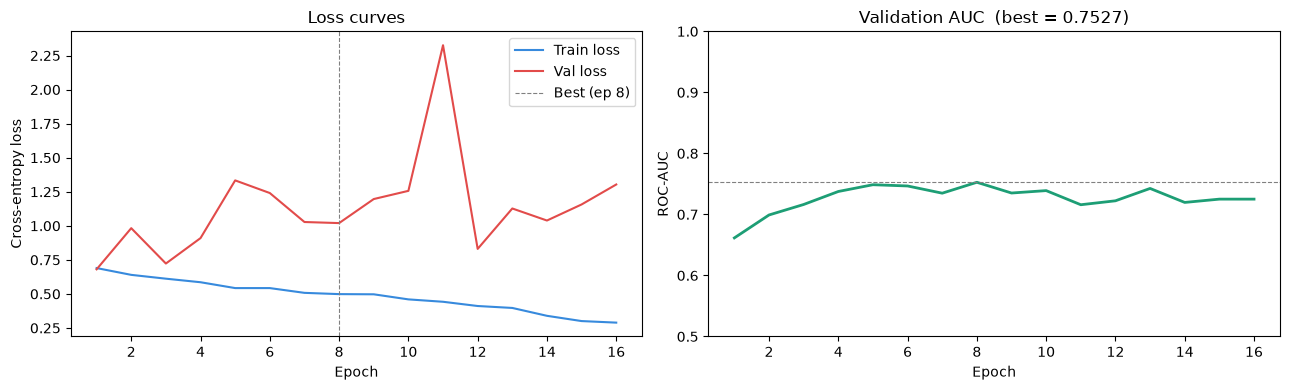

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, len(history['trn_loss']) + 1)
ax1.plot(ep, history['trn_loss'], label='Train loss', color='#378ADD')
ax1.plot(ep, history['val_loss'],  label='Val loss',   color='#E24B4A')
ax1.axvline(best_epoch, color='gray', linestyle='--', linewidth=0.8, label=f'Best (ep {best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Loss curves'); ax1.legend()

ax2.plot(ep, history['val_auc'], color='#1D9E75', linewidth=2)
ax2.axhline(best_auc, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC')
ax2.set_title(f'Validation AUC  (best = {best_auc:.4f})')
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(DATA_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 11 — Evaluate on held-out test set

=== Test Set Evaluation ===
ROC-AUC  : 0.7954

                  precision    recall  f1-score   support

  False Positive       0.67      0.90      0.77       218
Planet Candidate       0.85      0.57      0.68       223

        accuracy                           0.73       441
       macro avg       0.76      0.73      0.73       441
    weighted avg       0.76      0.73      0.73       441



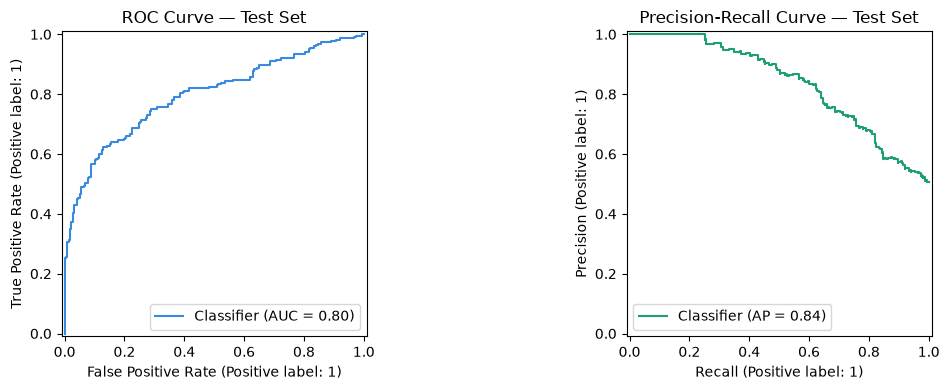

In [50]:
# Load best checkpoint
model.load_state_dict(torch.load(DATA_DIR / 'best_model.pt', map_location=DEVICE))
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for gv, lv, sf, y in dl_tst:
        gv, lv, sf = gv.to(DEVICE), lv.to(DEVICE), sf.to(DEVICE)
        probs = model.predict_proba(gv, lv, sf)
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(y.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= 0.5).astype(int)

print('=== Test Set Evaluation ===')
print(f'ROC-AUC  : {roc_auc_score(test_labels, test_probs):.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=['False Positive', 'Planet Candidate']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(test_labels, test_probs, ax=ax1, curve_kwargs={'color': '#378ADD'})
ax1.set_title('ROC Curve — Test Set')
PrecisionRecallDisplay.from_predictions(test_labels, test_probs, ax=ax2, curve_kwargs={'color': '#1D9E75'})
ax2.set_title('Precision-Recall Curve — Test Set')
plt.tight_layout()
plt.savefig(DATA_DIR / 'evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 12 — Export model for Flask backend

In [ ]:
# Save full model bundle — weights + architecture config
# This is what server.py will load
export_path = DATA_DIR / 'exodetect_cnn.pt'

torch.save({
    'model_state_dict':  model.state_dict(),
    'model_config': {
        'global_len': GLOBAL_VIEW_LEN,
        'local_len':  LOCAL_VIEW_LEN,
        'n_stellar':  4,
    },
    'preprocessing': {
        'global_view_len': GLOBAL_VIEW_LEN,
        'local_view_len':  LOCAL_VIEW_LEN,
        'local_width':     0.2,
        'smooth_window':   51,
    },
    'metrics': {
        'best_val_auc':  best_auc,
        'best_epoch':    best_epoch,
        'test_auc':      roc_auc_score(test_labels, test_probs),
        'n_train':       len(ds_trn),
        'n_val':         len(ds_val),
        'n_test':        len(ds_tst),
    }
}, export_path)

size_mb = export_path.stat().st_size / 1e6
print(f'✅ Model exported to: {export_path}')
print(f'   File size  : {size_mb:.1f} MB')
print(f'   Val AUC    : {best_auc:.4f}')
print(f'   Test AUC   : {roc_auc_score(test_labels, test_probs):.4f}')
print()
print('Next step: download exodetect_cnn.pt from the Files panel')
print('and place it in your backend folder alongside server.py')